# Проект ML

# 1 Исследование данных

### 1.1 Ознакомление с датасетом

**Датасет**: Loan Default

**Источник**: https://www.kaggle.com/datasets/yasserh/loan-default-dataset/data

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sn

# Импортируем датасет
df=pd.read_csv('dataset.csv')

df.shape

(148670, 34)

In [2]:
# Посмотрим на содержимое датасета
df.sample(5)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
116582,141472,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,EXP,638,CIB,25-34,not_inst,88.074713,North,direct,0,33.0
110598,135488,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CRIF,851,CIB,25-34,not_inst,45.712401,south,direct,0,31.0
129261,154151,2019,cf,Female,nopre,type1,p3,l1,nopc,nob/c,...,CIB,884,CIB,55-64,to_inst,30.807087,North-East,direct,0,34.0
119371,144261,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,642,CIB,45-54,not_inst,93.821839,south,direct,0,42.0
10245,35135,2019,cf,Joint,nopre,type2,p3,l1,nopc,b/c,...,CIB,655,EXP,55-64,to_inst,73.989899,central,direct,0,42.0


**Описание признаков:**
|№| Признак | Описание  |
|:-------------:|:------------- |:---------------|
|1| ID            | ID заявки клиента на кредит|
|2| year         | Год подачи заявки        |
|3| loan_limit        | Кредит конформный (cf) / неконформный (ncf) <br> <br>(Некомформный кредит - сумма превышает стандартный лимит на рынке)   |
|4| Gender        | Пол клиента <br> <br>(male, female, joint, sex not available)|
|5|approv_in_adv| Кредит одобрен (pre) или не одобрен (nopre) заранее |
|6|loan_type| Тип кредита (type1, type2, type3)|
|7|loan_purpose|Цель кредита (p1, p2, p3, p4)|
|8|Credit_Worthiness|Уровень кредитоспособности (l1, l2) <br> <br>l1 - высший уровень|
|9|open_credit| Есть ли активные кредиты у клиента (opc, nopc)|
|10|business_or_commercial|Кредит для бизнеса/коммерции или нет <br> <br>(ob/c - бизнес/коммерция, nob/c - личный кредит)|
|11|loan_amount| Сумма запрашиваемого кредита|
|12|rate_of_interest| Процентная ставка по кредиту|
||Interest_rate_spread| Процентный спред — разница между процентной ставкой по кредиту и эталонной (базовой) процентной ставкой|
|13|Upfront_charges| Авансовые платежи (или первоначальные сборы) — первоначальные расходы, связанные с оформлением/получением кредита|
|14|term| Срок кредита в месяцах|
|15|Neg_ammortization| Есть ли отрицательная аммортизация у кредита (neg_amm, not_neg) <br> <br> В некоторых странах есть кредиты с гибким платежом (Payment Option ARMs), допускающие отрицательную аммортизацию|
|16|interest_only| Есть ли у кредита опция оплаты только процентов - кредитные каникулы (int_only, not_int)|
|17|lump_sum_payment| Единовременный (крупный) платеж — указывает, требуется ли выплата всей оставшейся суммы долга одним чеком в конце срока кредита (lpsm, not_lpsm)|
|18|property_value| Стоимость финансируемого имущества, =N/A если объекта нет |
|19|construction_type| Тип  постройки объекта (sb - Капитальное строение, mh - Мобильный дом) |
|20|occupancy_type| Тип использования недвижимости <br> <br> (pr - Основное место жительства, sr- Второе жилье, ir - Инвестиционная недвижимость)|
|21|Secured_by| Тип залога (home, land)|
|22|total_units| Количество жилых единиц (квартир/блоков) в финансируемой недвижимости (1U, 2U, 3U, 4U)|
|23|income| Годовой доход клиента|
|24|credit_type| Тип кредитного бюро для проверки клиента <br> <br> (CIB - credit information bureau , CRIF - CIRF credit information bureau, EXP - experian , EQUI - equifax)|
|25|Credit_Score| Кредитный скоринг клиента|
|26|co-applicant_credit_type| Тип кредитного бюро для проверки со-заемщика <br> <br> (CIB - credit information bureau, EXP - experian)|
|27|age| Возраст клиента|
|28|submission_of_application| Способ подачи заявки (to_inst - напрямую, not_inst - не напрямую) |
|29|LTV| Отношение суммы кредита к сумме финансируемого объекта|
|30|Region| Географическое расположение объекта (North, south, central, North-East) |
|31|Security_Type| Тип обеспечения кредита (direct -прямое, indirect - косвенное ( с поручителем))|
|32|Status| Статус дефолта кредита. 1 - дефолт, 0 - не дефолт.|
|33|dtir1| Коэффициент долговой нагрузки (отношение общего долга к доходу)|

In [3]:
#Посмотрим на содержимое признаков: типы данных, кол-во заполненных строк.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            109028 non-nu

Датасет содержит 21 признак типа "object", эти признаки далее будет необходимо закодировать для возможности применения в модели. Также имеются пропущенные значения в ряде признаков. Их будет необходимо либо заполнить, либо удалить.

In [4]:
#Посмотрим на метрики числовых признаков:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


Из вышеуказанной информации можено выделить следующее:
- ID  -  указывает на ID заявки в системе, бесполезен для ML
- year - имеет только 2 значения 0 и 2019, следовательно бесполезен для ML
- LTV - max=7831.25 - очень сильное отклонение от mean, похоже на выброс или ошибку. Также учитывая, что LTV - это отношение суммы кредита от стоимости финансируемого объекта, и должен измеряться в **ДОЛЯХ** либо **ПРОЦЕНТАХ**,  значение 7831 здесь абсурдно (таких кредитов не бывает). Необходимо проанализировать признак.

### 1.2 Работа с аномалиями

In [5]:
#Посмотрим распределение значений LTV по перцентилям:
df['LTV'].quantile([0.1, 0.25, 0.5, 0.75, 0.95, 0.99])

0.10     46.394231
0.25     60.474860
0.50     75.135870
0.75     86.184211
0.95     98.728814
0.99    102.759740
Name: LTV, dtype: float64

99% данных в LTV находится в диапазоне (0;102), что  говорит о том, что признак измеряется в процентах. Теперь рассмотрим выбросы:

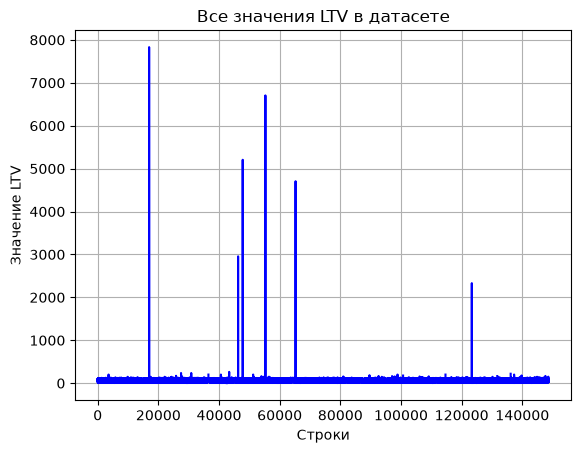

In [6]:
# В данном случае по диаграмме plt.hist трудно определить наличие выбросов, поэтому я использовала обычный график:
plt.plot(range(0, len(df)),df['LTV'], color='b')
plt.title("Все значения LTV в датасете")
plt.xlabel('Строки')
plt.ylabel('Значение LTV')
plt.grid()
plt.show()

График показал, что у признака 'LTV' имеется незначительное кол-во выбросов со значением выше 2000.

Поскольку LTV - это отношение суммы кредита (loan_amount) к стоимостьи финансируемого объекта (property_value), и в нашем датасете имеются оба этих признака, мы можем точно проверить верность значений LTV.

In [7]:
# Создаем 2 новых столбца - вычисленное значение LTV и разницу между вычисленным и исходном значениями LTV
# считаем LTV вручную
df['custom_LTV']=df['loan_amount']/df['property_value']*100
#Строки с разницей <1 будут иметь значение True
df['LTV_difference']=(abs(df['LTV']-df['custom_LTV'])>1)
# Строки где 'loan_amount','property_value','LTV' отсутствуют (NaN), имеют значение 'LTV_difference'=False, меняем их на NaN
df['LTV_difference']=np.where(df['loan_amount'].isna() |  df['property_value'].isna() |  df['LTV'].isna(), np.nan, df['LTV_difference'])
#python не хочет отображать boolean в формате True/False (показывал 1/0), поэтому сделала это  вручную
df['LTV_difference'] = df['LTV_difference'].replace({0.0: False, 1.0: True})
df['LTV_difference'] = df['LTV_difference'].astype(pd.BooleanDtype())
df['LTV_difference'].value_counts(dropna=False)

LTV_difference
False    133572
<NA>      15098
Name: count, dtype: Int64

Результат показал, что значения LTV вычислены верно - Все ненулевые значения 'LTV_difference' = False. Значит проблема в значениях 'loan_amount' или 'property_value', из которых считается LTV. Взглянем на выбросы>2000:

In [8]:
df[df['LTV']>2000][['loan_amount','property_value','LTV','custom_LTV','LTV_difference']]

,loan_amount,property_value,LTV,custom_LTV,LTV_difference
16951,626500,8000.0,7831.25,7831.25,False
46287,236500,8000.0,2956.25,2956.25,False
47807,416500,8000.0,5206.25,5206.25,False
55286,536500,8000.0,6706.25,6706.25,False
65238,376500,8000.0,4706.25,4706.25,False
123343,186500,8000.0,2331.25,2331.25,False


Значения property_value похожи на аномалию, скорее всего исчисляются в тысячах. Т.к. обычно сумма заема меньше стоимости приобретаемого объекта, а не наоборот. Попробуем исправить эти значения умножив на 1000:

In [9]:
df.loc[df['LTV'] > 2000, 'property_value'] *= 1000
#Сдедом необходимо обновить значения 'LTV'
df.loc[df['LTV'] > 2000, 'LTV'] = df['loan_amount'] / df['property_value']*100

#Проверяем изменения:
df[df['custom_LTV']>2000][['loan_amount','property_value','LTV','custom_LTV','LTV_difference']]

,loan_amount,property_value,LTV,custom_LTV,LTV_difference
16951,626500,8000000.0,7.83125,7831.25,False
46287,236500,8000000.0,2.95625,2956.25,False
47807,416500,8000000.0,5.20625,5206.25,False
55286,536500,8000000.0,6.70625,6706.25,False
65238,376500,8000000.0,4.70625,4706.25,False
123343,186500,8000000.0,2.33125,2331.25,False


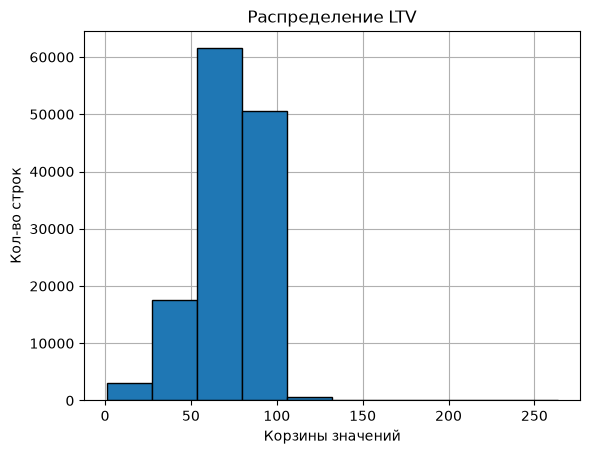

In [10]:
#Заново посмотрим на распределение LTV
plt.hist(df['LTV'], bins = 10, edgecolor='black',zorder=2)
plt.title("Распределение LTV")
plt.xlabel('Корзины значений')
plt.ylabel('Кол-во строк')
plt.grid(zorder=0)
plt.show()

Гистограмма показывает, что у нас имеются   довольно высокие но реалистичные значения  LTV (от 100% до 250%). Не будем их удалять, т.к. признаков достаточно много, и могут присутствовать неочевидные закономерности.

In [11]:
#Столбцы 'custom_LTV' и 'LTV_difference' больше не нужны, можно их удалить
df=df.drop(['custom_LTV' , 'LTV_difference'], axis=1)

### 1.3 Очистка датасета

Как было сказано ранее, признаки 'ID' 'year' не несут пользы для обучения, поэтому удалим их:

In [12]:
df=df.drop(['ID','year'], axis=1)

Посмотрим, сколько % пропущенных значений в каждом признаке:

In [13]:
df.isna().mean().round(2)*100

loan_limit                    2.0
Gender                        0.0
approv_in_adv                 1.0
loan_type                     0.0
loan_purpose                  0.0
Credit_Worthiness             0.0
open_credit                   0.0
business_or_commercial        0.0
loan_amount                   0.0
rate_of_interest             25.0
Interest_rate_spread         25.0
Upfront_charges              27.0
term                          0.0
Neg_ammortization             0.0
interest_only                 0.0
lump_sum_payment              0.0
property_value               10.0
construction_type             0.0
occupancy_type                0.0
Secured_by                    0.0
total_units                   0.0
income                        6.0
credit_type                   0.0
Credit_Score                  0.0
co-applicant_credit_type      0.0
age                           0.0
submission_of_application     0.0
LTV                          10.0
Region                        0.0
Security_Type 

В датасете имеется до 27% пропущенных значений для части признаков. Заполнение 27% исказит результат обучения, Попробуем избавиться от строк с пропущенными значениями. Но  сначала проверим влияние на 'Status' (целевой признак):

In [14]:
# Разделим датасет на ә части - с пустыми значениями и без пустых значений.
df_with_nans = df[df.isna().any(axis=1)]
df_without_nans = df[~df.index.isin(df_with_nans.index)]

In [15]:
# Проверим баланс классов в каждом датафрейме:
df['Status'].value_counts(normalize=True)

Status
0    0.753555
1    0.246445
Name: proportion, dtype: float64

In [16]:
df_with_nans['Status'].value_counts(normalize=True)

Status
1    0.725769
0    0.274231
Name: proportion, dtype: float64

In [17]:
df_without_nans['Status'].value_counts(normalize=True)

Status
0    1.0
Name: proportion, dtype: float64

Мы видим что в части датасета, где есть пропуски, содержатся **ВСЕ** дефолтные кредиты, поэтому удалять эти данные категорически нельзя. Я удалю только часть df_with_nans со статусом 0, остальное придется заполнить.

In [18]:
df_with_nans_0 = df[(df['Status'] == 0) & (df.isna().any(axis=1))]
df = df.drop(df_with_nans_0.index)
df.shape

(134826, 32)

Итого удалилось 13844 строки и 2 столбца. Новый размер датасета: (134826, 32)

### 1.4 Missingness Indicator

Перед заполнением пропусков применим метод индикаторных переменных (Missingness Indicator) - создадим бинарные признаки-маркеры для каждого столбца с пропусками со значением True если пропуск есть, False если нет. Таким образом мы превращаем отсутсвтвтие данных в отдельный признак, который будет иметь свой вес.

In [19]:
# Находим только те столбцы, где  есть пропуски
cols_with_nan = [col for col in df.columns if df[col].isna().any()]

for col in cols_with_nan:

    # Имя нового признака-маркера
    flag_name = f'{col}_is_nan'

    # 1 - если пропуск, 0 - если число
    df[flag_name] = df[col].isna().astype(int)
    df[flag_name] = df[col].isna().astype(int)

Непосредственно само заполнение данных будем делать после Split (Будем использовать метод MICE).

### 1.5 Кодирование категориальных данных

У нас имеется 21 категориальный признак. Необходимо их закодировать. Будем использовать метод One-Hot Encoding.


In [20]:
#Собираем object-признаки в список
object_columns = df.select_dtypes(include=['object', 'string']).columns.tolist()

for col in object_columns:
  df[col]=pd.Categorical(df[col])

df_encoded=pd.get_dummies(df, columns=object_columns, drop_first=True, dtype=int)

In [21]:
df_encoded

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,...,age_45-54,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_to_inst,Region_North-East,Region_central,Region_south,Security_Type_direct
0,116500,NaN,NaN,NaN,360.0,118000.0,1740.0,758,98.728814,1,...,0,0,0,0,0,1,0,0,1,1
1,206500,NaN,NaN,NaN,360.0,NaN,4980.0,552,NaN,1,...,0,1,0,0,0,1,0,0,0,1
2,406500,4.560,0.2000,595.00,360.0,508000.0,9480.0,834,80.019685,0,...,0,0,0,0,0,1,0,0,1,1
4,696500,4.000,0.3042,0.00,360.0,758000.0,10440.0,602,91.886544,0,...,0,0,0,0,0,0,0,0,0,1
5,706500,3.990,0.1523,370.00,360.0,1008000.0,10080.0,864,70.089286,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,436500,3.125,0.2571,9960.00,180.0,608000.0,7860.0,659,71.792763,0,...,0,1,0,0,0,1,0,0,1,1
148666,586500,5.190,0.8544,0.00,360.0,788000.0,7140.0,569,74.428934,0,...,0,0,0,0,0,0,0,0,1,1
148667,446500,3.125,0.0816,1226.64,180.0,728000.0,6900.0,702,61.332418,0,...,1,0,0,0,0,0,0,0,0,1
148668,196500,3.500,0.5824,4323.33,180.0,278000.0,7140.0,737,70.683453,0,...,0,1,0,0,0,1,0,0,0,1


У нас получилось 63 признака. Можно переходить к обучению.

# 2 Подготовка к обучению

### 2.1 Исследовательские вопросы

1. *Какие признаки сильнее всего влияют на вероятность дефолта заемщика?*

2. *Какая модель машинного обучения лучше и точнее всего справляется с предсказанием дефолта на наших данных?*

3. *Где находится точка баланса (порог классификации) между риском упустить прибыль (отказать хорошему клиенту) и риском понести убытки от дефолта?*

In [22]:
### 2.2 Баланс классов
df_encoded['Status'].value_counts(normalize=True)

Status
0    0.72825
1    0.27175
Name: proportion, dtype: float64

### 2.2 Split данных

In [23]:
y=df_encoded['Status']
X=df_encoded.drop('Status', axis=1)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,y,train_size=0.8,random_state=42,stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((107860, 62), (26966, 62), (107860,), (26966,))

### 2.3 Заполнение данных

После сплита данных можем начать заполнение пропусков. Используем метод MICE - минирегрессия

In [25]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Cтроки для заполнения - находим заново после кодировки данных:
cols_with_nan = [col for col in df_encoded.columns if df_encoded[col].isna().any()]

# Инициализируем импутер
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

# Обучаем MICE на тренировочной выборке и сразу заполняем столбцы
X_train[cols_with_nan] = mice_imputer.fit_transform(X_train[cols_with_nan])

# Применяем обученные правила на тестовую выборку
X_test[cols_with_nan] = mice_imputer.transform(X_test[cols_with_nan])

In [26]:
X_train.isna().any().sum(), X_test.isna().any().sum()

(np.int64(0), np.int64(0))

In [27]:
cols_with_nan

['rate_of_interest',
 'Interest_rate_spread',
 'Upfront_charges',
 'term',
 'property_value',
 'income',
 'LTV',
 'dtir1']

### 2.4 Визуализация ключевых зависимостей (корреляция)

Построим heatmap корреляции между признаками датасета:

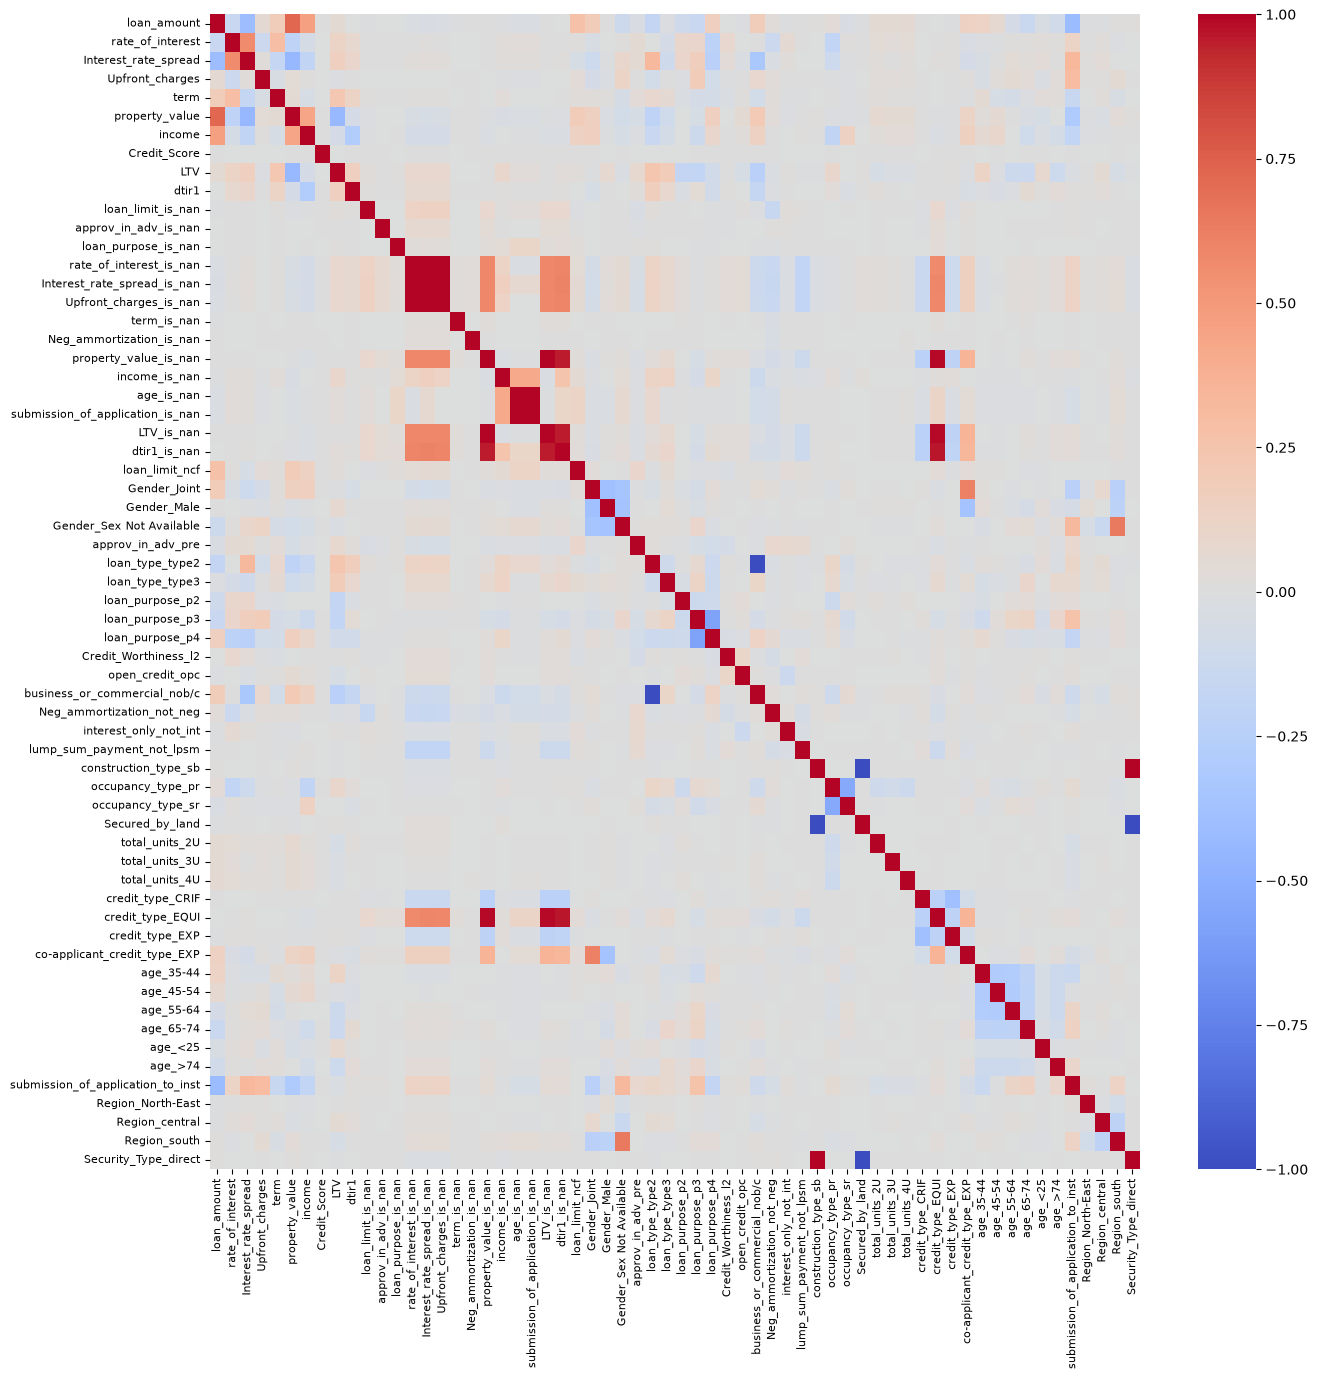

In [28]:
cols=X_train.columns
corr=X_train[cols].corr()

plt.figure(figsize=(15,15))
sn.heatmap(corr, fmt='.2f', cmap='coolwarm')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

In [29]:
# 1. Считаем матрицу корреляции для числовых данных
corr_matrix = X_train.corr()

# 2. Превращаем матрицу в плоскую таблицу (столбец пар)
corr_table = corr_matrix.unstack().reset_index()
corr_table.columns = ['Признак_1', 'Признак_2', 'Коэффициент_Корреляции']

# 3. Фильтруем таблицу:
# - убираем связь признака с самим собой (где корреляция равна 1.0)
# - оставляем только пары, где корреляция по модулю >= 0.3
corr_table_todel = corr_table[(corr_table['Признак_1'] != corr_table['Признак_2']) & (corr_table['Признак_1']!='Status') & (corr_table['Признак_2']!='Status') & (abs(corr_table['Коэффициент_Корреляции'])>0.8)]
cols_todel = np.unique(corr_table_todel['Признак_1'].values)
cols_todel

array(['Interest_rate_spread_is_nan', 'LTV_is_nan', 'Secured_by_land',
       'Security_Type_direct', 'Upfront_charges_is_nan', 'age_is_nan',
       'business_or_commercial_nob/c', 'construction_type_sb',
       'credit_type_EQUI', 'dtir1_is_nan', 'loan_type_type2',
       'property_value_is_nan', 'rate_of_interest_is_nan',
       'submission_of_application_is_nan'], dtype=object)

Признаки с высокой мультиколлинеарностью необходимо удалить, т.к. они дублируют информацию и ухудшают модель.

In [30]:
cols_todel = cols_todel.tolist()
X_train=X_train.drop(columns=cols_todel)
X_test=X_test.drop(columns=cols_todel)

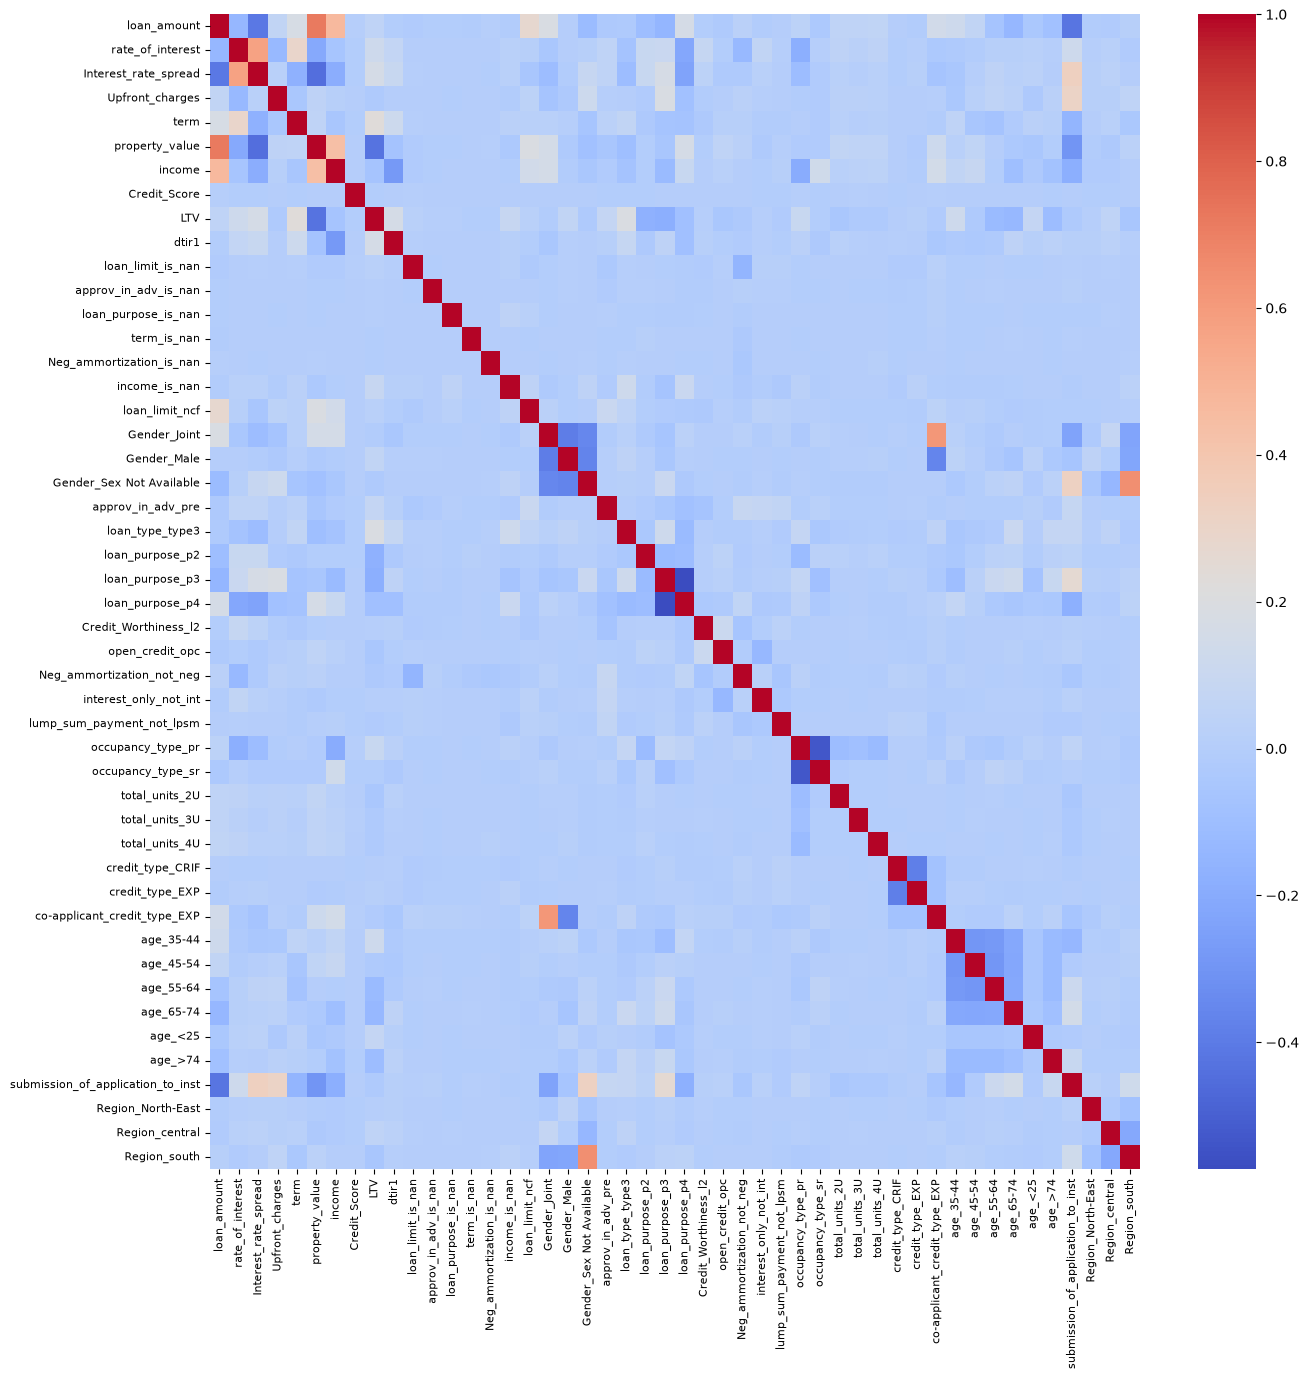

In [31]:
 # Построим заново теполвую карту корреляции
cols=X_train.columns
corr=X_train[cols].corr()

plt.figure(figsize=(15,15))
sn.heatmap(corr, fmt='.2f', cmap='coolwarm')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

Теперь карта выглядит корректно. Наибольшая корреляция признаков наблюдается только по отношению к себе (красная диагональ).
Посмотрим на новый размер датасетов -  кол-во столбцов уменьшилось с 62 до 48

In [32]:
X_train.shape, X_test.shape

((107860, 48), (26966, 48))

# 3 Нормализация данных

In [33]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# 4 Построение модели - Классификация

Дефолт будет - 1, дефолта не будет - 0.
Рассмотрим 2 ошибки:
1) Ошибка 1 рода - некритическая:
Модель ошибочно предсказывает большинству клиентов дефолт, в результате Банк не несет убытков, но упускает выгоду от выдачи кредитов, которые в реальности были недефолтными, но предсказаны как дефоолтные.

2) Ошибка 2 рода - критическая:
Суть задачи классификации при выявлении дефолта кредита - минимизировать False Negative, т.е. предсказания "Дефолта не будет", когда в реальности дефолт наступил. Банк, веря модели, выдаст кредит клиенту. Далее наступает дефолт, клиент перестает платить, банк теряет ВСЁ с основного долга ( и проценты и тело кредита). Процесс взыскания через суд или продажа залога отнимут годы и покроют лишь часть убытков. Уровень неработающих кредитов (NPL) резко растет.

### 4.1 KNN

Начнем с метода близжайших K-соседей

In [34]:
from sklearnex import patch_sklearn
patch_sklearn()

from tqdm import tqdm  # Красивый индикатор прогресса
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score

# Ваши параметры (сократим для теста, убрав тяжелые алгоритмы)
k_list = list(range(1, 31, 2))
weights_list = ['uniform', 'distance']
metrics_list = ['euclidean']
algorithms_list = ['brute']
best_roc_auc = 0
best_params = {}

# Считаем общее количество шагов для полосы прогресса
total_iterations = len(k_list) * len(weights_list) * len(metrics_list) *len(algorithms_list)

with tqdm(total=total_iterations, desc="Подбор параметров") as pbar:
    for metric in metrics_list:
        for weight in weights_list:
            for algorithm in algorithms_list:
                for k in k_list:
                
                    # Создаем модель. Алгоритм 'brute' идеален для Intel Intelex!
                    knn = KNeighborsClassifier(n_neighbors=k, weights=weight, metric=metric, algorithm=algorithm)
                
                    # Запускаем кросс-валидацию
                    # scores вернет массив из 5 оценок (для 5 фолдов)
                    rocauc_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='roc_auc', n_jobs=2)
                    rocauc_mean_score = rocauc_scores.mean()
                
                    # Логика REFIT: выбираем лучшую модель строго по ROC-AUC
                    if rocauc_mean_score > best_roc_auc:
                       best_roc_auc = rocauc_mean_score
                       best_params = {'n_neighbors': k, 'weights': weight, 'algorithms': algorithm, 'metrics': metric}

                    pbar.update(1)
                
print(f'[Итог] Лучшие параметры по ROC-AUC: {best_params}')

# Финальный шаг REFIT (руками): обучаем модель на всей выборке
knn_best = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'], 
                                   weights=best_params['weights'], 
                                   metric=best_params['metrics'], algorithm=best_params['algorithms'])
knn_best.fit(X_train_scaled, y_train) 
print("Финальная модель обучена и готова к работе!")       
print("\nОптимальные параметры:", best_params)
print(f"Лучшая точность  ROC-AUC на обучении: {best_roc_auc:.4f}")
y_pred_proba = knn_best.predict_proba(X_test_scaled)[:, 1]
roc_auc_knn = roc_auc_score(y_test, y_pred_proba)
print(f"Лучшая точность  ROC-AUC на тесте: {roc_auc_knn:.4f}")


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)
Подбор параметров: 100%|██████████| 30/30 [05:05<00:00, 10.18s/it]


[Итог] Лучшие параметры по ROC-AUC: {'n_neighbors': 19, 'weights': 'distance', 'algorithms': 'brute', 'metrics': 'euclidean'}
Финальная модель обучена и готова к работе!

Оптимальные параметры: {'n_neighbors': 19, 'weights': 'distance', 'algorithms': 'brute', 'metrics': 'euclidean'}
Лучшая точность  ROC-AUC на обучении: 0.8997
Лучшая точность  ROC-AUC на тесте: 0.9052


In [35]:
y_pred_knn=knn_best.predict(X_test_scaled)
# Сохраняем отчет в датафрейм
report_dict = classification_report(y_test, y_pred_knn, target_names=['Не дефолт','Дефолт'], output_dict=True)
knn_full_report = pd.DataFrame(report_dict).transpose()
# Округляем до 4 знаков
knn_full_report = knn_full_report.round(4)
knn_full_report

,precision,recall,f1-score,support
Не дефолт,0.8816,0.9232,0.9019,19638.0000
Дефолт,0.7644,0.6677,0.7128,7328.0000
accuracy,0.8538,0.8538,0.8538,0.8538
macro avg,0.8230,0.7955,0.8074,26966.0000
weighted avg,0.8498,0.8538,0.8505,26966.0000


In [36]:
from sklearn.metrics import recall_score, precision_score, f1_score
recall_score(y_test, y_pred_knn)

0.6677128820960698

In [37]:
threshold=[0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
result=[]
y_pred_proba = knn_best.predict_proba(X_test_scaled)
for t in threshold:
  y_pred_t=(y_pred_proba[:,1]>=t).astype(int)
  result.append({
      'threshold': t,
      'Precision': precision_score(y_test,y_pred_t),
      'Recall': recall_score(y_test,y_pred_t),
      'F1': f1_score(y_test,y_pred_t)
  })

result=pd.DataFrame(result)
result

,threshold,Precision,Recall,F1
0,0.05,0.340319,0.992767,0.506880
1,0.10,0.377242,0.981714,0.545041
2,0.20,0.466572,0.941867,0.624022
3,0.30,0.572236,0.870224,0.690450
4,0.40,0.672560,0.768286,0.717243
5,0.50,0.764412,0.667713,0.712798
6,0.60,0.831156,0.573008,0.678352
7,0.70,0.886250,0.483761,0.625883


### 4.2 Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression

# Задаем параметры
c_list = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
l1_ratio_list = [0, 1]
solver_list=[ 'liblinear', 'saga']
class_weight_list= [None, 'balanced']
best_roc_auc = 0
best_params = {}
results_history = [] # Сюда сохраним всё, чтобы потом посмотреть глазами

total_iterations = len(c_list) * len(l1_ratio_list) *len(solver_list) *len (class_weight_list)

with tqdm(total=total_iterations, desc="Обучение Логистической регрессии") as pbar:
    for l1_ratio in l1_ratio_list:
        for c in c_list:
            for solver in solver_list:
                    for class_weight in class_weight_list:
                        # Создаем модель. max_iter=1000 защищает от ошибки "не сошлось" (Failed to converge)
                        lr = LogisticRegression(C=c, l1_ratio=l1_ratio, solver=solver, class_weight=class_weight, max_iter=2000, random_state=42)
                        
                        # Считаем Accuracy (дефолтная быстрая метрика для выбора параметров)
                        # n_jobs=1 гарантирует, что 8 ГБ ОЗУ не перегрузятся
                        roc_auc_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, n_jobs=2)
                        mean_roc_auc_lr = roc_auc_lr.mean()
                        
                        # Сохраняем результаты в список, чтобы данные не потерялись
                        results_history.append({'C': c, 'l1_ratio': l1_ratio, 'mean_roc_auc_lr': mean_roc_auc_lr})
                        
                        # Логика сохранения лучшего результата
                        if mean_roc_auc_lr > best_roc_auc:
                            best_roc_auc = mean_roc_auc_lr
                            best_params = {'C': c, 'l1_ratio': l1_ratio, 'solver': solver, 'class_weight': class_weight}
            
                        pbar.update(1)
            
# Финальный шаг REFIT (руками): обучаем модель на всей выборке
lr_best = LogisticRegression(C=best_params['C'], 
                                   l1_ratio=best_params['l1_ratio'],solver=best_params['solver'],class_weight=best_params['class_weight']  )
lr_best.fit(X_train_scaled, y_train) 
print("\n[Итог] Лучшие параметры для логистической модели:", best_params)
print(f"Лучший ROC-AUC на обучении: {best_roc_auc:.4f}")
y_pred_proba = lr_best.predict_proba(X_test_scaled)[:, 1]
roc_auc_knn = roc_auc_score(y_test, y_pred_proba)
print(f"Лучший ROC-AUC на тесте: {best_roc_auc:.4f}")
# --- Полноценный вывод результатов после завершения (чтобы проанализировать глазами) ---
print("\nПолная история расчетов:")
for res in results_history:
    print(f"C={res['C']:<5} | l1_ratio={res['l1_ratio']:<2} -> mean_roc_auc_lr: {res['mean_roc_auc_lr']:.4f}")

important_coef = pd.DataFrame({
    'Признак': X_train.columns,
    'Коэффициент': lr_best.coef_[0]
}).sort_values(by='Коэффициент', key=abs, ascending=False)

Обучение Логистической регрессии: 100%|██████████| 48/48 [37:50<00:00, 47.30s/it] 



[Итог] Лучшие параметры для логистической модели: {'C': 0.1, 'l1_ratio': 0, 'solver': 'saga', 'class_weight': None}
Лучший ROC-AUC на обучении: 0.8033
Лучший ROC-AUC на тесте: 0.8033

Полная история расчетов:
C=0.001 | l1_ratio=0  -> mean_roc_auc_lr: 0.8016
C=0.001 | l1_ratio=0  -> mean_roc_auc_lr: 0.7331
C=0.001 | l1_ratio=0  -> mean_roc_auc_lr: 0.8007
C=0.001 | l1_ratio=0  -> mean_roc_auc_lr: 0.7350
C=0.01  | l1_ratio=0  -> mean_roc_auc_lr: 0.8030
C=0.01  | l1_ratio=0  -> mean_roc_auc_lr: 0.7342
C=0.01  | l1_ratio=0  -> mean_roc_auc_lr: 0.8030
C=0.01  | l1_ratio=0  -> mean_roc_auc_lr: 0.7343
C=0.1   | l1_ratio=0  -> mean_roc_auc_lr: 0.8032
C=0.1   | l1_ratio=0  -> mean_roc_auc_lr: 0.7342
C=0.1   | l1_ratio=0  -> mean_roc_auc_lr: 0.8033
C=0.1   | l1_ratio=0  -> mean_roc_auc_lr: 0.7342
C=1.0   | l1_ratio=0  -> mean_roc_auc_lr: 0.8032
C=1.0   | l1_ratio=0  -> mean_roc_auc_lr: 0.7342
C=1.0   | l1_ratio=0  -> mean_roc_auc_lr: 0.8032
C=1.0   | l1_ratio=0  -> mean_roc_auc_lr: 0.7342
C=10.0

C:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [39]:
y_pred_lr=lr_best.predict(X_test_scaled)
# Сохраняем отчет в датафрейм
report_dict = classification_report(y_test, y_pred_lr, target_names=['Не дефолт','Дефолт'], output_dict=True)
lr_full_report = pd.DataFrame(report_dict).transpose()
# Округляем до 4 знаков
lr_full_report = lr_full_report.round(4)
lr_full_report

,precision,recall,f1-score,support
Не дефолт,0.8113,0.9483,0.8745,19638.0000
Дефолт,0.7469,0.4091,0.5287,7328.0000
accuracy,0.8018,0.8018,0.8018,0.8018
macro avg,0.7791,0.6787,0.7016,26966.0000
weighted avg,0.7938,0.8018,0.7805,26966.0000


In [40]:
#Теперь найдем наилучшее значение порога для наивысшего значения Recall
from sklearn.metrics import precision_score, recall_score, f1_score

threshold=[0.05,0.1,0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
result=[]
y_pred_proba = lr_best.predict_proba(X_test_scaled)

for t in threshold:
  y_pred_t=(y_pred_proba[:,1]>=t).astype(int)
  result.append({
      'threshold': t,
      'Precision': precision_score(y_test,y_pred_t),
      'Recall': recall_score(y_test,y_pred_t),
      'F1': f1_score(y_test,y_pred_t)
  })

result=pd.DataFrame(result)
# result=result[result['Recall']==result['Recall'].max()]
result


,threshold,Precision,Recall,F1
0,0.05,0.278012,0.990721,0.434185
1,0.10,0.318474,0.932997,0.474858
2,0.20,0.416623,0.762691,0.538881
3,0.30,0.540351,0.630459,0.581937
4,0.40,0.655963,0.515693,0.577431
5,0.50,0.746886,0.409116,0.528655
6,0.60,0.826996,0.296807,0.436835
7,0.70,0.887654,0.196234,0.321413


In [41]:
important_coef=important_coef.sort_values(by='Коэффициент', ascending=False)
pos_weights=important_coef.head(5)
neg_weights=important_coef.tail(5)

In [42]:
pos_weights

,Признак,Коэффициент
15,income_is_nan,0.792936
10,loan_limit_is_nan,0.745732
37,co-applicant_credit_type_EXP,0.685920
44,submission_of_application_to_inst,0.373545
8,LTV,0.365383


In [43]:
neg_weights

,Признак,Коэффициент
29,lump_sum_payment_not_lpsm,-0.394500
6,income,-0.401815
36,credit_type_EXP,-0.416076
35,credit_type_CRIF,-0.428858
17,Gender_Joint,-0.534719


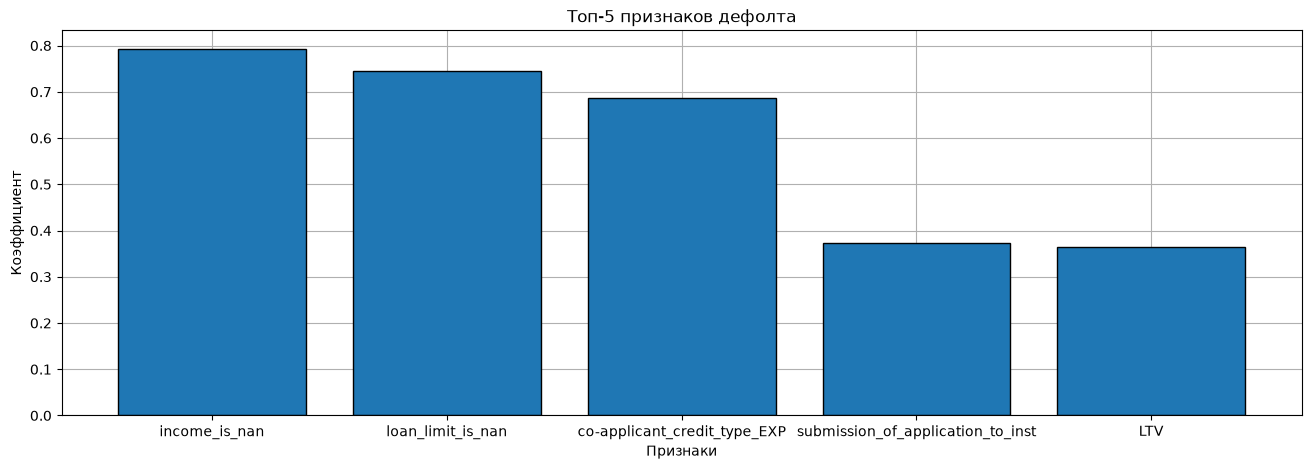

In [44]:
plt.figure(figsize=(16,5))
plt.bar(x=pos_weights['Признак'], height= pos_weights['Коэффициент'], edgecolor='black',zorder=2)
plt.title("Топ-5 признаков дефолта")
plt.xlabel('Признаки')
plt.ylabel('Коэффициент')
plt.grid(zorder=0)
plt.show()

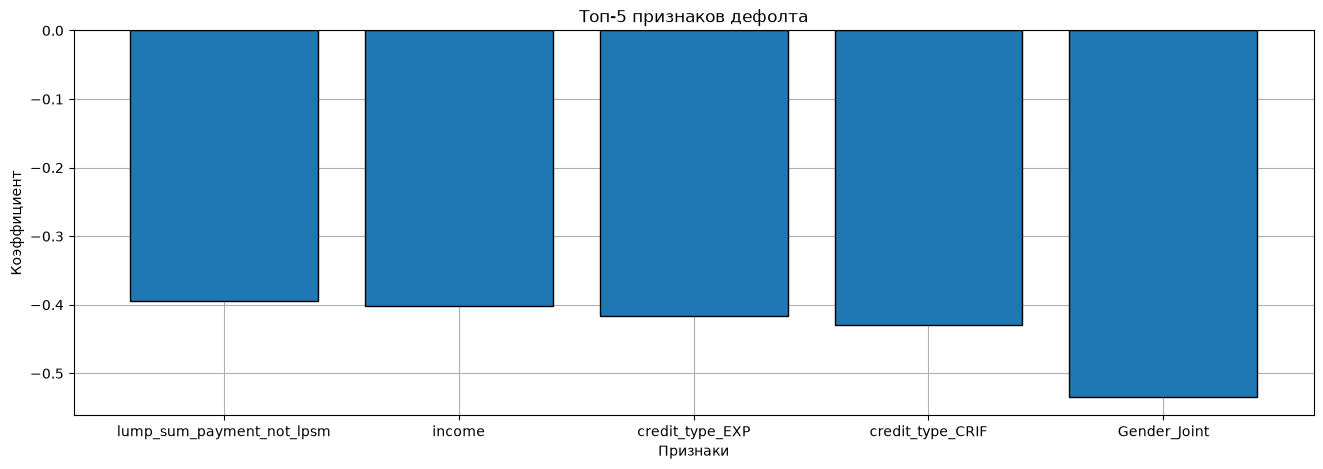

In [45]:
plt.figure(figsize=(16,5))
plt.bar(x=neg_weights['Признак'], height= neg_weights['Коэффициент'], edgecolor='black',zorder=2)
plt.title("Топ-5 признаков дефолта")
plt.xlabel('Признаки')
plt.ylabel('Коэффициент')
plt.grid(zorder=0)
plt.show()

### 4.3 SVM

In [48]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV

c_list = [0.01, 0.1, 1.0, 10.0, 100]
# gamma_list = ['scale', 'auto']
# class_weight_list = ['balanced', None]

best_roc_auc = 0
best_params = {}

for c in c_list:
    # 1. Создаем быстрый линейный SVM (зафиксируем, например, C=0.1)
    svm = SVC(C=c, class_weight='balanced', max_iter=1000)
    
    # 2. Оборачиваем в калибратор, чтобы модель умела выдавать вероятности
    # Используем cv='prefit', чтобы сначала обучить модель, а потом откалибровать, 
    # либо передаем структуру вашего cv (StratifiedKFold) для внутренней калибровки.
    calibrated_svm = CalibratedClassifierCV(estimator=svm, method='sigmoid', cv=5)

    # 3. Обучаем модель на ВСЕХ тренировочных данных
    calibrated_svm.fit(X_train_scaled, y_train)

    # 4. Получаем вероятности для тестовой выборки
    y_pred_proba_svm = calibrated_svm.predict_proba(X_test_scaled)[:, 1]
    roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm)
    if roc_auc_svm > best_roc_auc:
        best_roc_auc = roc_auc_svm
        best_params = {'C': c}

svm_best = SVC(C=best_params['C'], probability=True)          
svm_best.fit(X_train_scaled, y_train)          
print(f'\nЛучшие параметры: {best_params} ')
print(f'\nЛучший ROC-AUC на тесте: {best_roc_auc:.4f}')

C:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearnex\svm\_base.py:662: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Лучшие параметры: {'C': 100} 

Лучший ROC-AUC на тесте: 0.9972


In [ ]:
y_pred_svm=svm_best.predict(X_test_scaled)
# Сохраняем отчет в датафрейм
report_dict = classification_report(y_test, y_pred_svm, target_names=['Не дефолт','Дефолт'], output_dict=True)
svm_full_report = pd.DataFrame(report_dict).transpose()
# Округляем до 4 знаков
svm_full_report = svm_full_report.round(4)
svm_full_report

In [ ]:
result=[]
y_pred_proba = svm_best.predict_proba(X_test_scaled)

for t in threshold:
  y_pred_t=(y_pred_proba[:,1]>=t).astype(int)
  result.append({
      'threshold': t,
      'Precision': precision_score(y_test,y_pred_t),
      'Recall': recall_score(y_test,y_pred_t),
      'F1': f1_score(y_test,y_pred_t)
  })

result=pd.DataFrame(result)
result
# result=result[result['Recall']==result['Recall'].max()]

In [ ]:
from sklearn.metrics import precision_recall_curve

y_pred_proba_knn = knn_best.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_knn)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision (Точность)', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall (Полнота)', color='orange')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Поиск точки баланса через Precision и Recall')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Находим индекс, где абсолютная разница между Precision и Recall минимальна
# Мы используем precision[:-1], так как длина массивов precision и recall на 1 больше, чем thresholds
diff = np.abs(precision[:-1] - recall[:-1])
intersect_idx = np.argmin(diff)

# Вытаскиваем координаты
intersect_threshold = thresholds[intersect_idx]
intersect_value = precision[intersect_idx] # В этой точке Precision примерно равен Recall

print(f"Координаты точки пересечения:")
print(f"X (Порог классификации): {intersect_threshold:.4f}")
print(f"Y (Значение Precision и Recall): {intersect_value:.4f}")

In [ ]:
from sklearn.metrics import precision_recall_curve

y_pred_proba_lr = lr_best.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_lr)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision (Точность)', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall (Полнота)', color='orange')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Поиск точки баланса через Precision и Recall')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Находим индекс, где абсолютная разница между Precision и Recall минимальна
# Мы используем precision[:-1], так как длина массивов precision и recall на 1 больше, чем thresholds
diff = np.abs(precision[:-1] - recall[:-1])
intersect_idx = np.argmin(diff)

# Вытаскиваем координаты
intersect_threshold = thresholds[intersect_idx]
intersect_value = precision[intersect_idx] # В этой точке Precision примерно равен Recall

print(f"Координаты точки пересечения:")
print(f"X (Порог классификации): {intersect_threshold:.4f}")
print(f"Y (Значение Precision и Recall): {intersect_value:.4f}")

In [ ]:
y_pred_proba_svm = svm_best.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_svm)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision (Точность)', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall (Полнота)', color='orange')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Поиск точки баланса через Precision и Recall')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Находим индекс, где абсолютная разница между Precision и Recall минимальна
# Мы используем precision[:-1], так как длина массивов precision и recall на 1 больше, чем thresholds
diff = np.abs(precision[:-1] - recall[:-1])
intersect_idx = np.argmin(diff)

# Вытаскиваем координаты
intersect_threshold = thresholds[intersect_idx]
intersect_value = precision[intersect_idx] # В этой точке Precision примерно равен Recall

print(f"Координаты точки пересечения:")
print(f"X (Порог классификации): {intersect_threshold:.4f}")
print(f"Y (Значение Precision и Recall): {intersect_value:.4f}")

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(9, 7))

# Строим кривую для KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (ROC-AUC = {roc_auc_score(y_test, y_pred_proba_knn):.4f})', color='purple')

# Строим кривую для Логистической регрессии
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Логистическая регрессия (ROC-AUC = {roc_auc_score(y_test, y_pred_proba_lr):.4f})', color='blue', lw=2)

# Строим кривую для Linear SVC
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)
plt.plot(fpr_svm, tpr_svm, label=f'Linear SVC (ROC-AUC = {roc_auc_score(y_test, y_pred_proba_svm):.4f})', color='green')

# Линия случайного угадывания (диагональ)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор (ROC-AUC = 0.5)')

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Доля ложных тревог)')
plt.ylabel('True Positive Rate (Доля угаданных дефолтов)')
plt.title('Сравнение ROC-кривых для всех моделей на тестовой выборке', fontsize=13, pad=15)
plt.legend(loc="best")
plt.grid(True)
plt.show()